In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc

In [2]:
df = pd.read_csv('/content/ai_workforce_displacement_global_2020_2026.csv')

In [6]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   record_id                               20800 non-null  int64  
 1   country                                 20800 non-null  object 
 2   iso3_code                               20800 non-null  object 
 3   region                                  20800 non-null  object 
 4   income_group                            20800 non-null  object 
 5   year                                    20800 non-null  int64  
 6   quarter                                 20800 non-null  int64  
 7   industry_sector                         20800 non-null  object 
 8   sector_automation_risk_score            20800 non-null  float64
 9   gdp_per_capita_usd                      20800 non-null  int64  
 10  ai_adoption_index                    

In [7]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
          record_id          year       quarter  sector_automation_risk_score  \
count  20800.000000  20800.000000  20800.000000                  20800.000000   
mean   10400.500000   2022.769231      2.423077                      0.537881   
std     6004.587135      1.887406      1.115411                      0.190345   
min        1.000000   2020.000000      1.000000                      0.151000   
25%     5200.750000   2021.000000      1.000000                      0.379000   
50%    10400.500000   2023.000000      2.000000                      0.580000   
75%    15600.250000   2024.000000      3.000000                      0.698000   
max    20800.000000   2026.000000      4.000000                      0.855000   

       gdp_per_capita_usd  ai_adoption_index  pct_sector_workforce_displaced  \
count        20800.000000       20800.000000                    20800.000000   
mean         21003.330769           0.692148                        0.056155   
std  

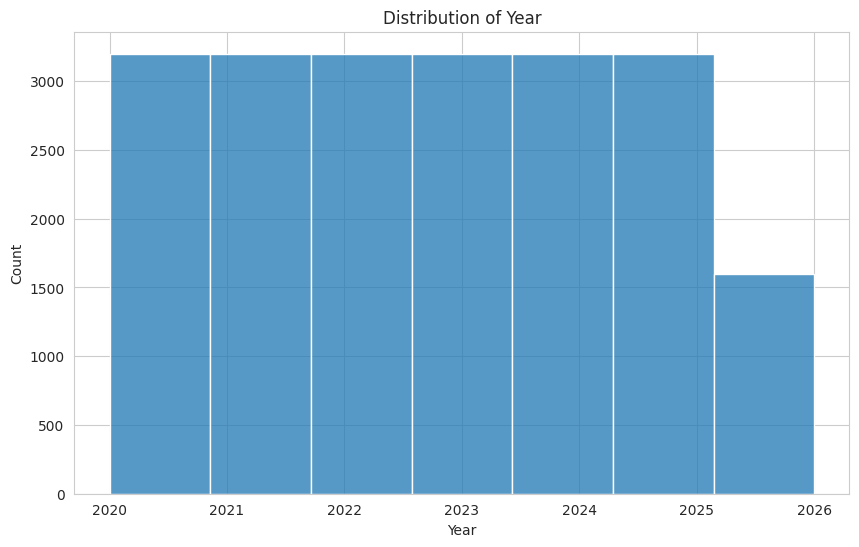

In [8]:
# Set style for plots
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['year'], bins=len(df['year'].unique()), kde=False)
plt.title('Distribution of Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

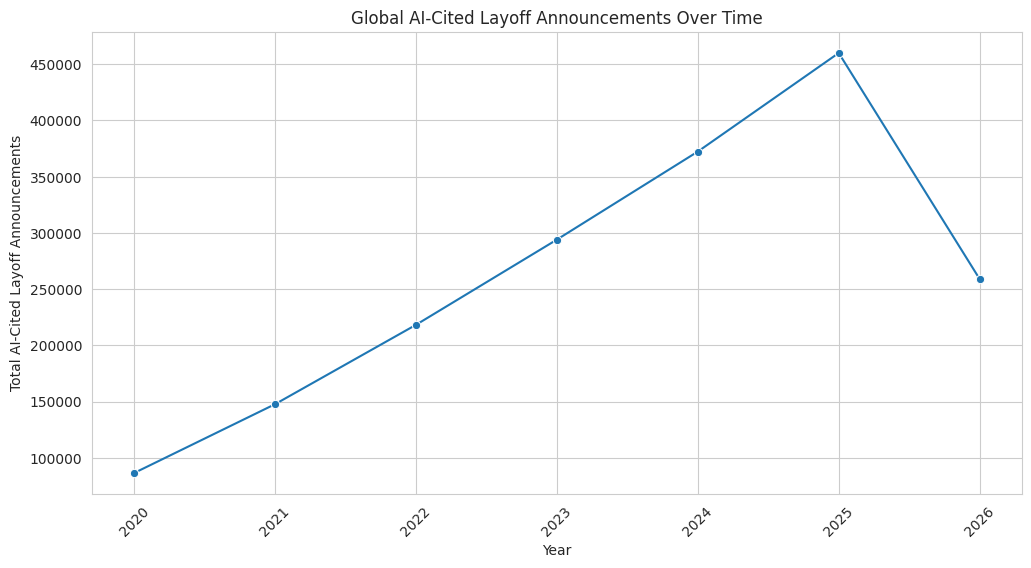

In [9]:
# Aggregate data for global displacement trends
global_displacement_yearly = df.groupby('year')['ai_cited_layoff_announcements'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=global_displacement_yearly, x='year', y='ai_cited_layoff_announcements', marker='o')
plt.title('Global AI-Cited Layoff Announcements Over Time')
plt.xlabel('Year')
plt.ylabel('Total AI-Cited Layoff Announcements')
plt.xticks(rotation=45)
plt.show()

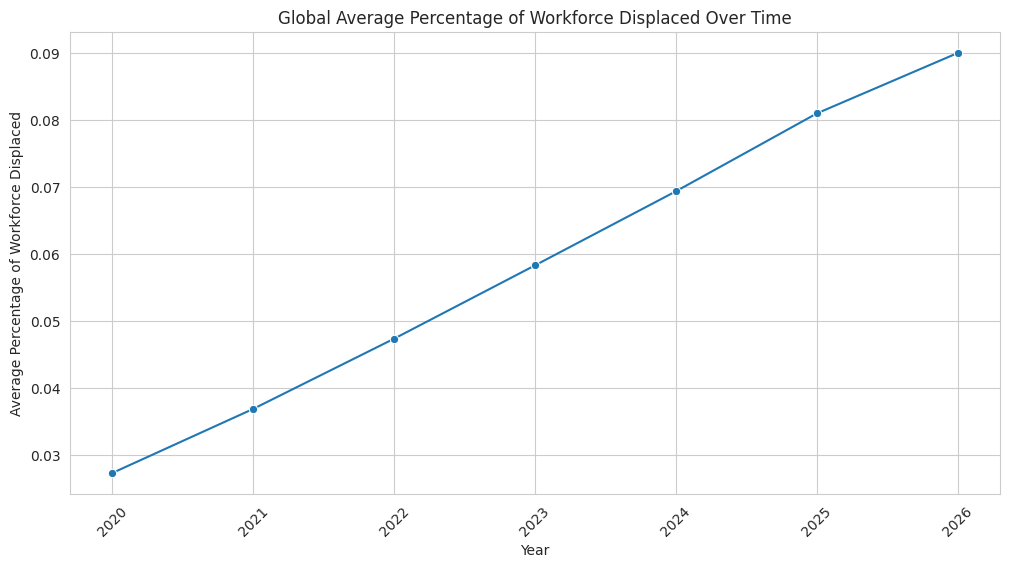

In [10]:
global_pct_workforce_displaced_yearly = df.groupby('year')['pct_sector_workforce_displaced'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=global_pct_workforce_displaced_yearly, x='year', y='pct_sector_workforce_displaced', marker='o')
plt.title('Global Average Percentage of Workforce Displaced Over Time')
plt.xlabel('Year')
plt.ylabel('Average Percentage of Workforce Displaced')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_8223/2009938268.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='ai_cited_layoff_announcements', y='country', palette='viridis')


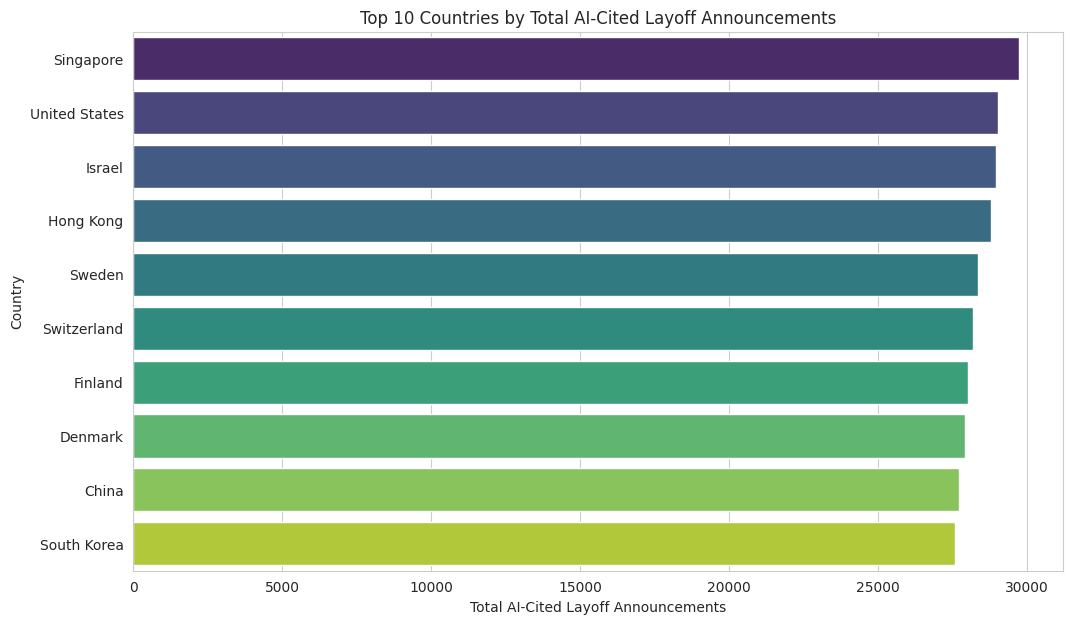

In [11]:
# Top 10 Countries by AI-Cited Layoff Announcements
top_countries = df.groupby('country')['ai_cited_layoff_announcements'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12, 7))
sns.barplot(data=top_countries, x='ai_cited_layoff_announcements', y='country', palette='viridis')
plt.title('Top 10 Countries by Total AI-Cited Layoff Announcements')
plt.xlabel('Total AI-Cited Layoff Announcements')
plt.ylabel('Country')
plt.show()

/tmp/ipykernel_8223/3096337271.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_displacement, x='ai_cited_layoff_announcements', y='region', palette='magma')


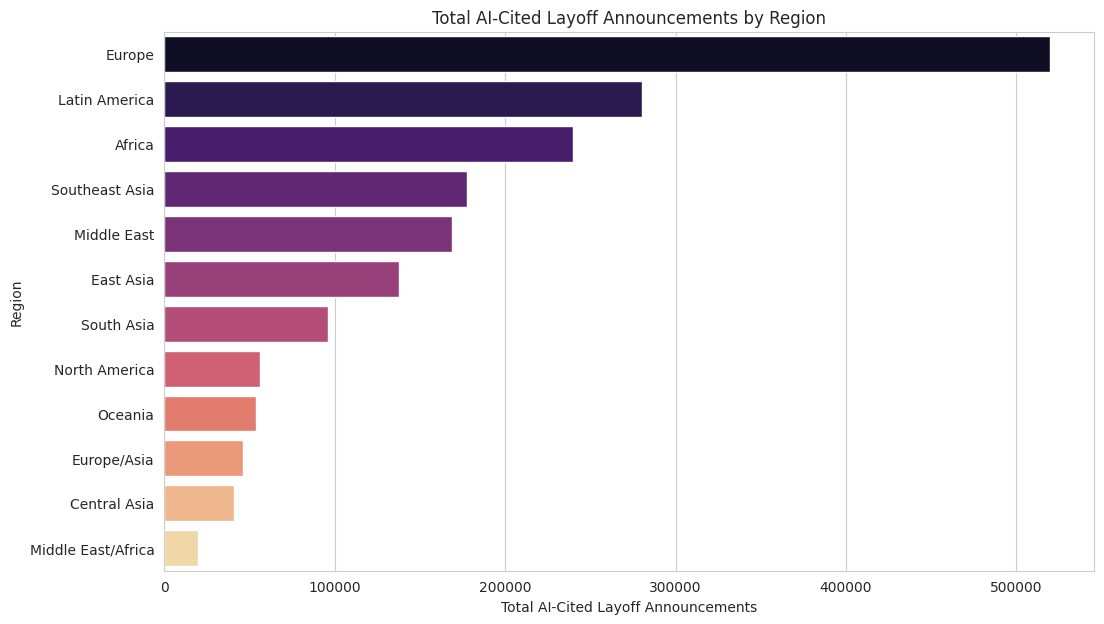

In [12]:
# AI-Cited Layoff Announcements by Region
region_displacement = df.groupby('region')['ai_cited_layoff_announcements'].sum().reset_index().sort_values(by='ai_cited_layoff_announcements', ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(data=region_displacement, x='ai_cited_layoff_announcements', y='region', palette='magma')
plt.title('Total AI-Cited Layoff Announcements by Region')
plt.xlabel('Total AI-Cited Layoff Announcements')
plt.ylabel('Region')
plt.show()


/tmp/ipykernel_8223/1148774214.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sector_jobs_displaced, x='pct_sector_workforce_displaced', y='industry_sector', palette='cividis')


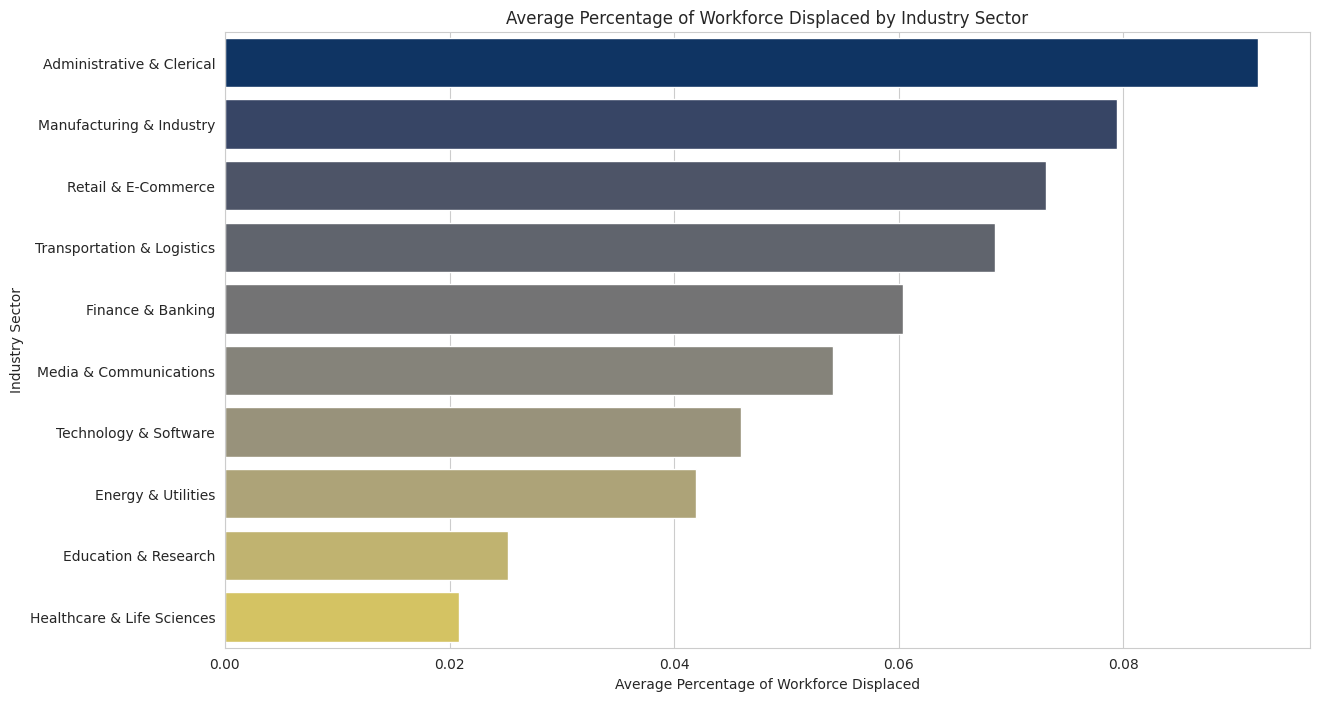

In [13]:
# Percentage of Workforce Displaced by Industry Sector
sector_jobs_displaced = df.groupby('industry_sector')['pct_sector_workforce_displaced'].mean().reset_index().sort_values(by='pct_sector_workforce_displaced', ascending=False)
plt.figure(figsize=(14, 8))
sns.barplot(data=sector_jobs_displaced, x='pct_sector_workforce_displaced', y='industry_sector', palette='cividis')
plt.title('Average Percentage of Workforce Displaced by Industry Sector')
plt.xlabel('Average Percentage of Workforce Displaced')
plt.ylabel('Industry Sector')
plt.show()


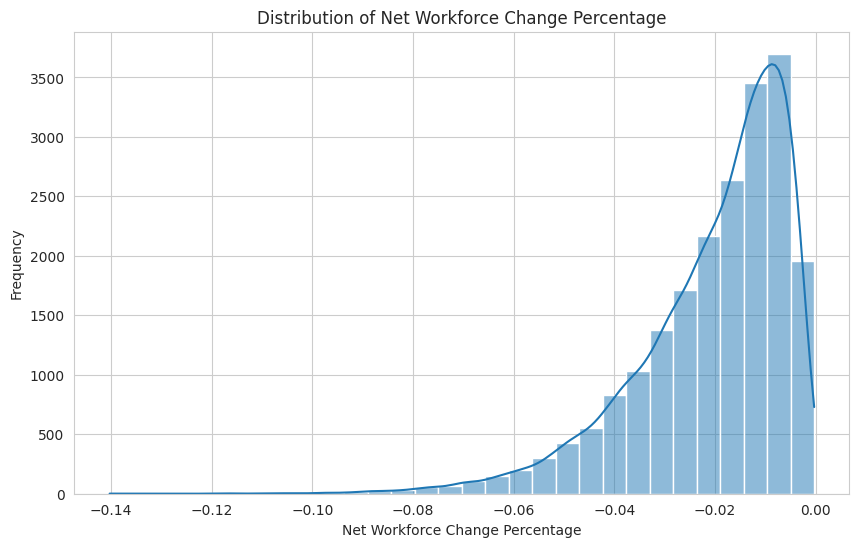

In [14]:
# Distribution of Net Workforce Change Percentage
plt.figure(figsize=(10, 6))
sns.histplot(df['net_workforce_change_pct'].dropna(), bins=30, kde=True)
plt.title('Distribution of Net Workforce Change Percentage')
plt.xlabel('Net Workforce Change Percentage')
plt.ylabel('Frequency')
plt.show()

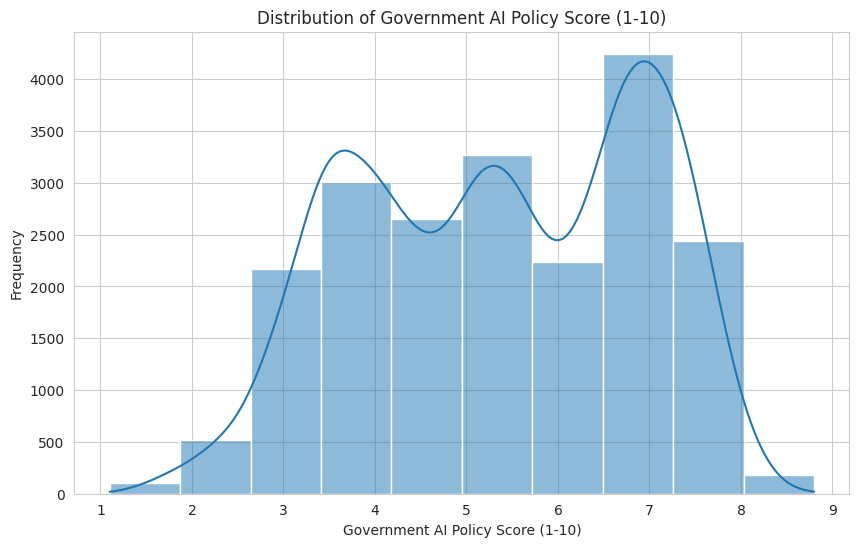

In [18]:
# Distribution of Government AI Policy Score (1 to 10)
plt.figure(figsize=(10, 6))
sns.histplot(df['govt_ai_policy_score_1_to_10'].dropna(), bins=10, kde=True) # Assuming score is 1 to 10, 10 bins would be appropriate
plt.title('Distribution of Government AI Policy Score (1-10)')
plt.xlabel('Government AI Policy Score (1-10)')
plt.ylabel('Frequency')
plt.show()

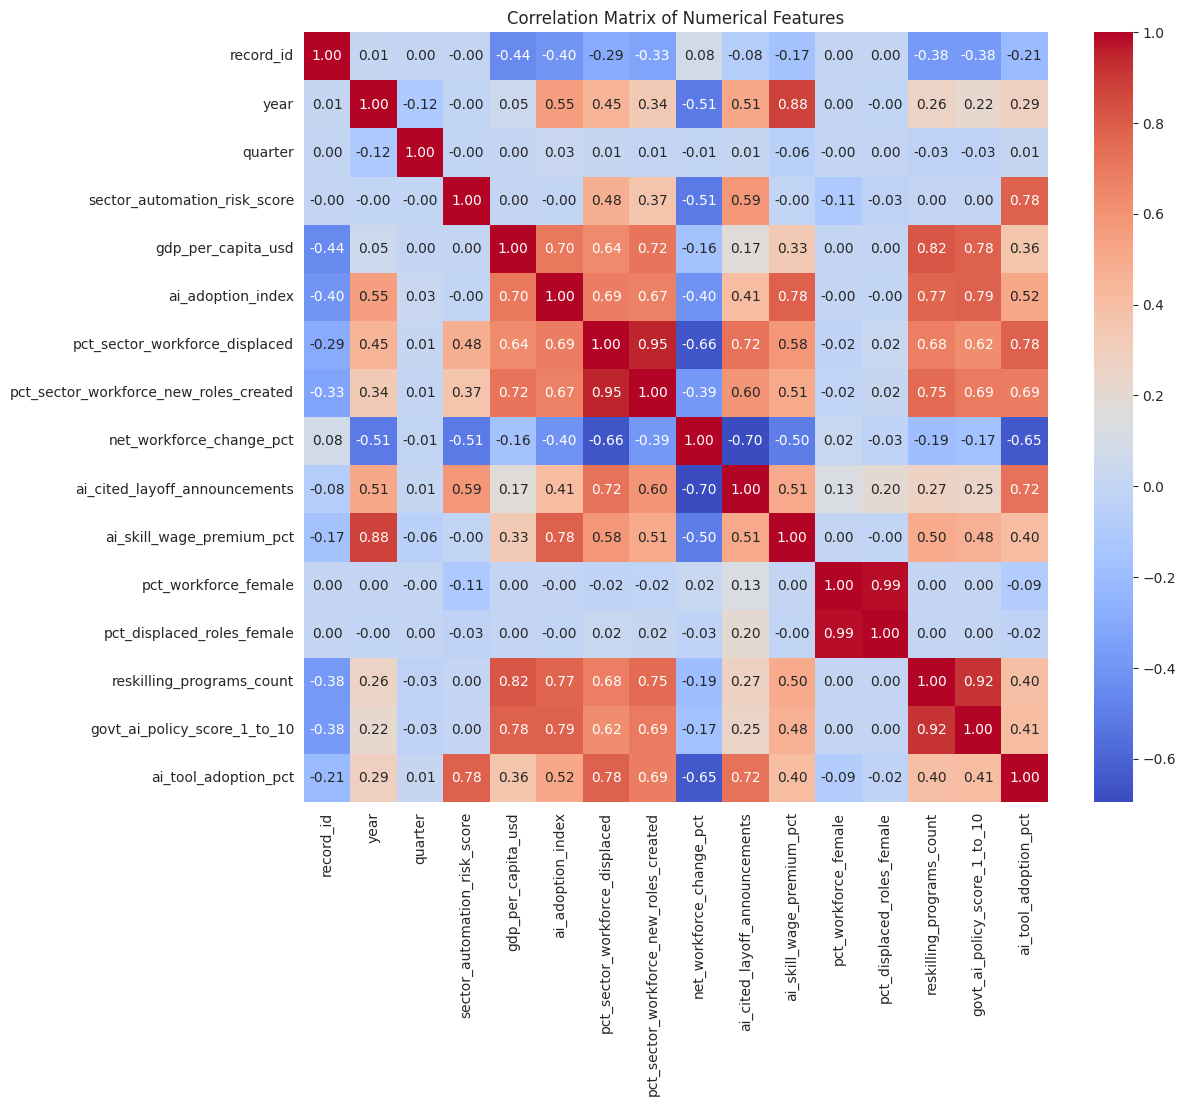

In [17]:
# Correlation Matrix for numerical columns
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

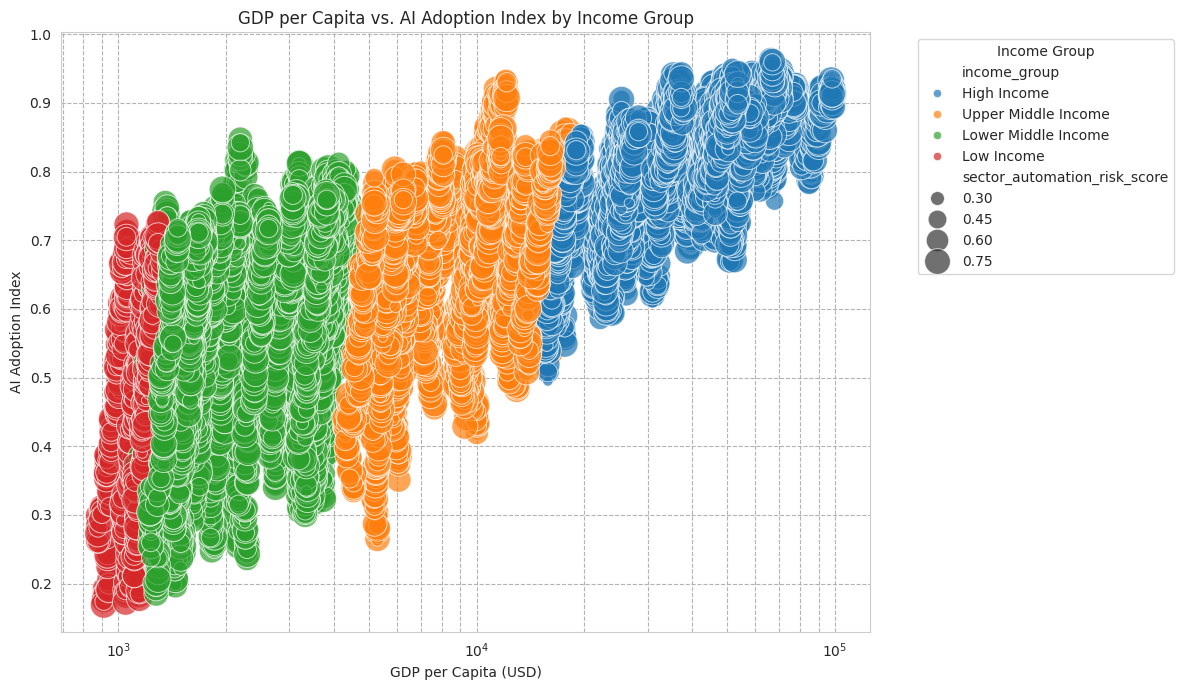

In [22]:
# Scatter plot: GDP per Capita vs. AI Adoption Index
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='gdp_per_capita_usd', y='ai_adoption_index', hue='income_group', size='sector_automation_risk_score', sizes=(20, 400), alpha=0.7)
plt.title('GDP per Capita vs. AI Adoption Index by Income Group')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('AI Adoption Index')
plt.xscale('log') # Use log scale for better visualization of GDP
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()

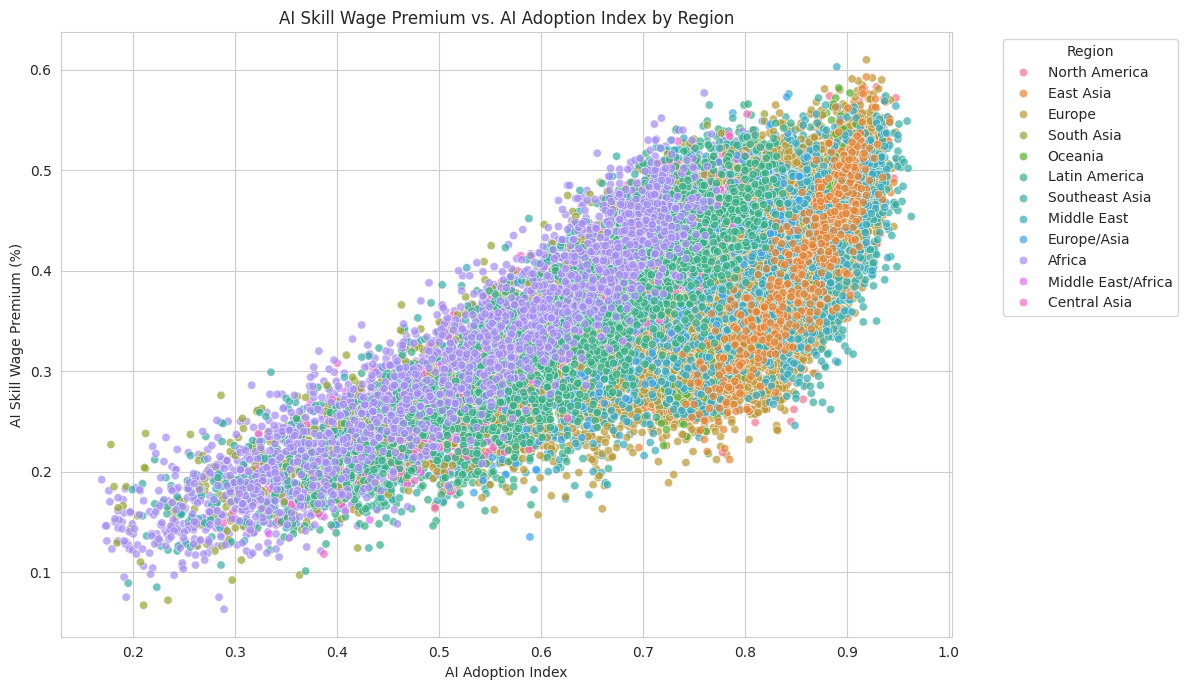

In [23]:

# Scatter plot: AI Skill Wage Premium vs. AI Adoption Index
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='ai_adoption_index', y='ai_skill_wage_premium_pct', hue='region', alpha=0.7)
plt.title('AI Skill Wage Premium vs. AI Adoption Index by Region')
plt.xlabel('AI Adoption Index')
plt.ylabel('AI Skill Wage Premium (%)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

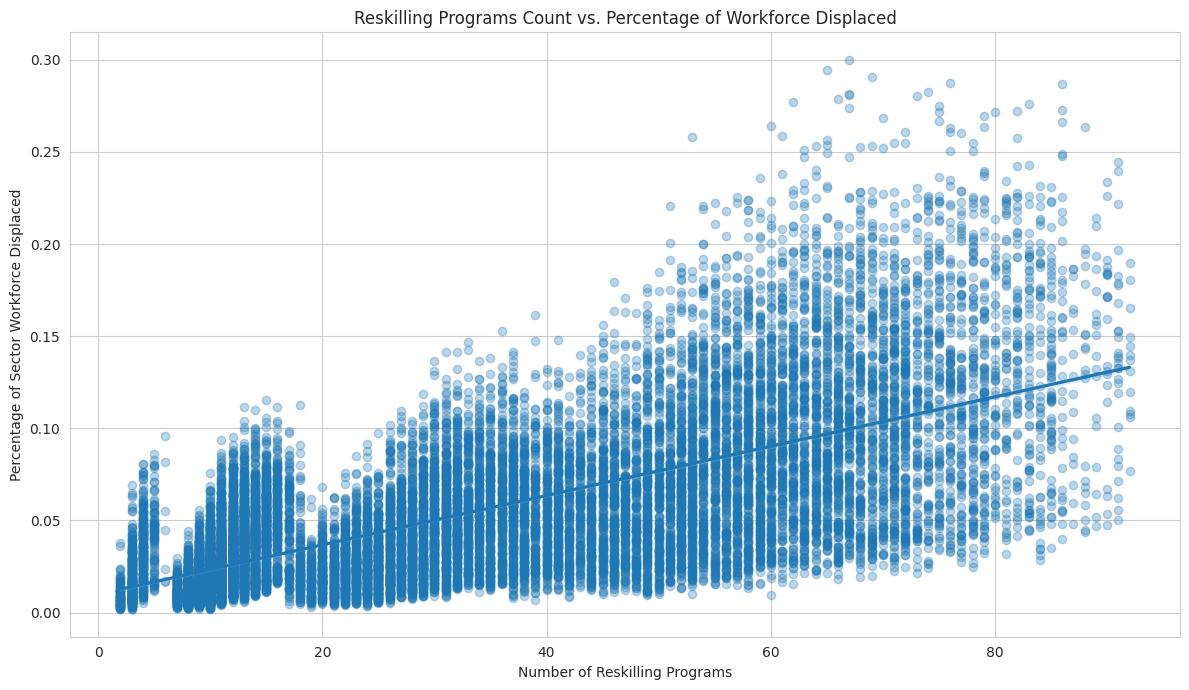

In [24]:
# Reskilling Programs Count vs. Percentage of Workforce Displaced
plt.figure(figsize=(12, 7))
sns.regplot(data=df, x='reskilling_programs_count', y='pct_sector_workforce_displaced', scatter_kws={'alpha':0.3})
plt.title('Reskilling Programs Count vs. Percentage of Workforce Displaced')
plt.xlabel('Number of Reskilling Programs')
plt.ylabel('Percentage of Sector Workforce Displaced')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8223/3344369308.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income_group', y='net_workforce_change_pct', palette='pastel')


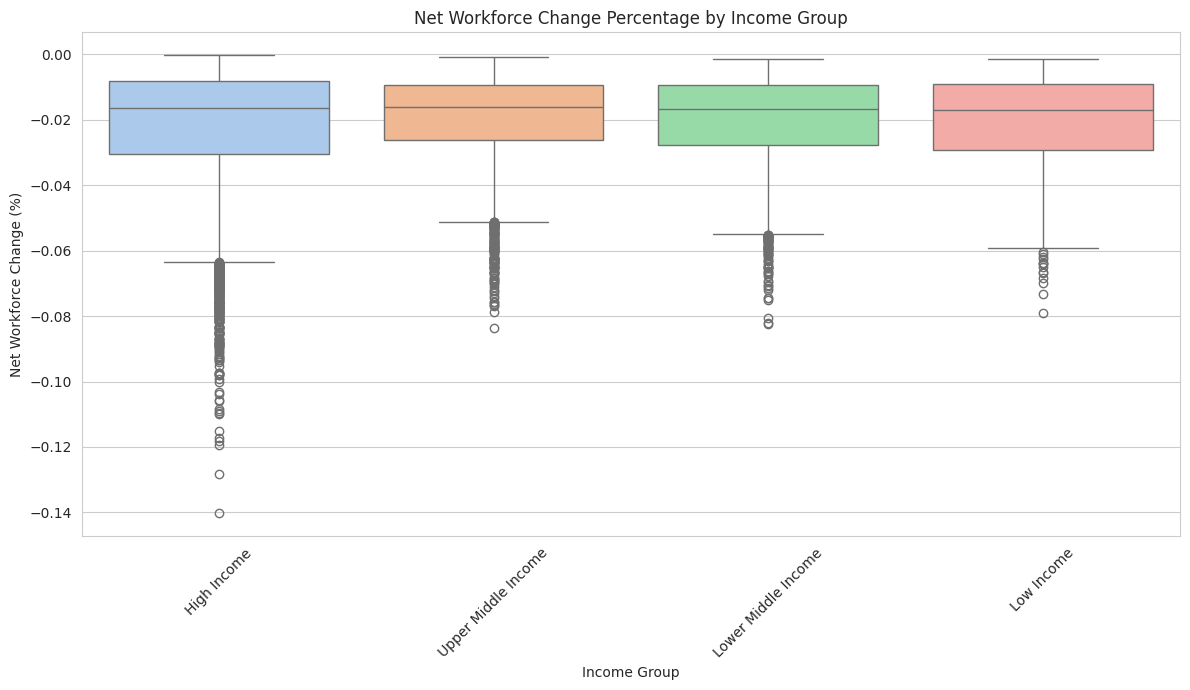

In [25]:

# Box plot: Net Workforce Change by Income Group
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='income_group', y='net_workforce_change_pct', palette='pastel')
plt.title('Net Workforce Change Percentage by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Net Workforce Change (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

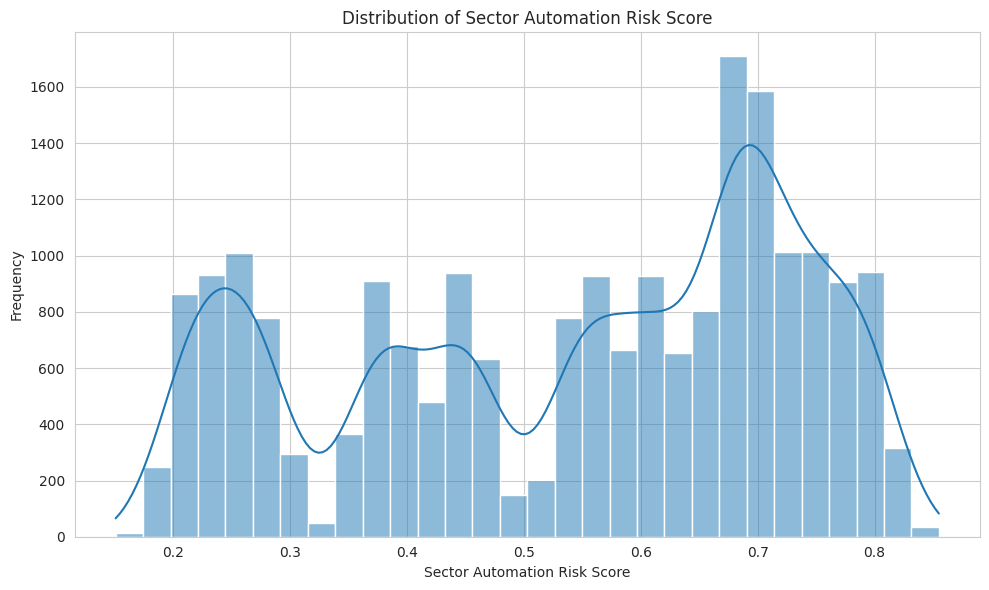

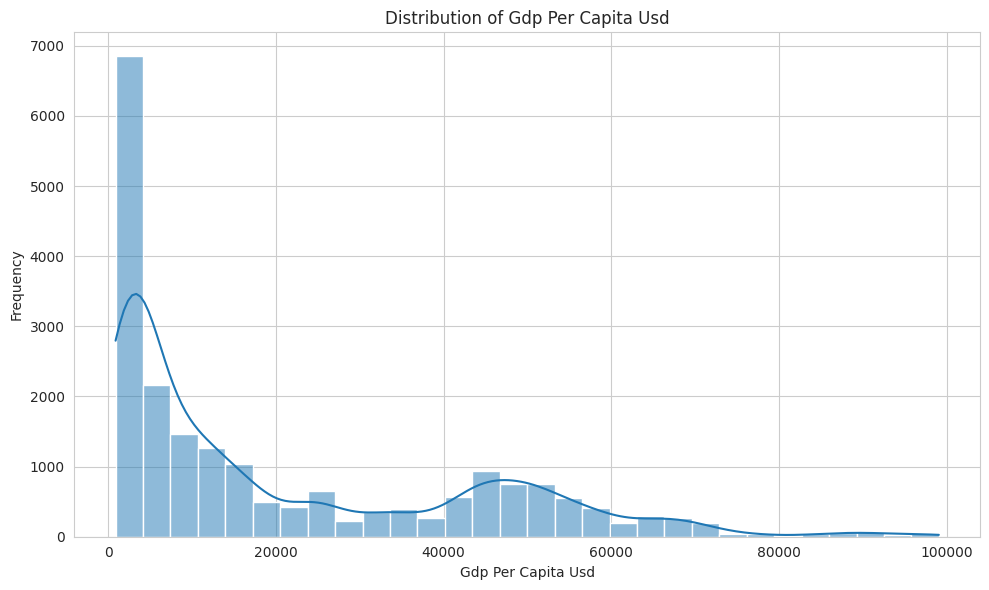

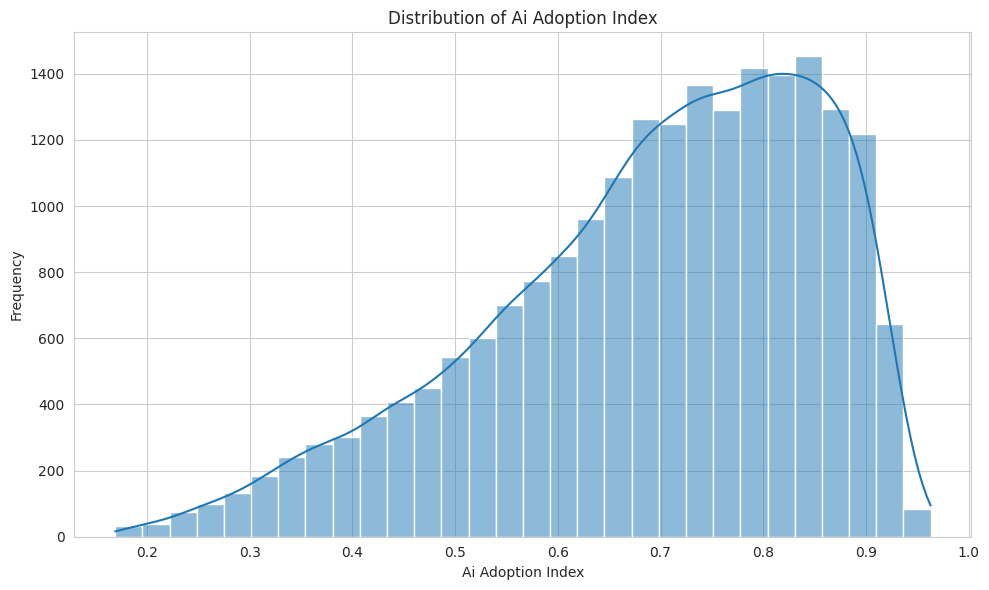

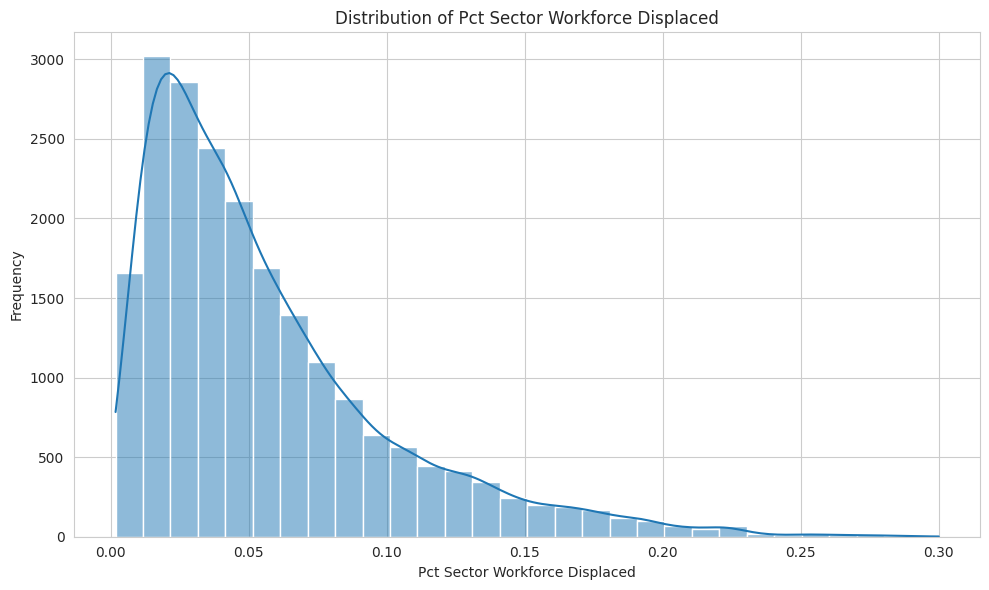

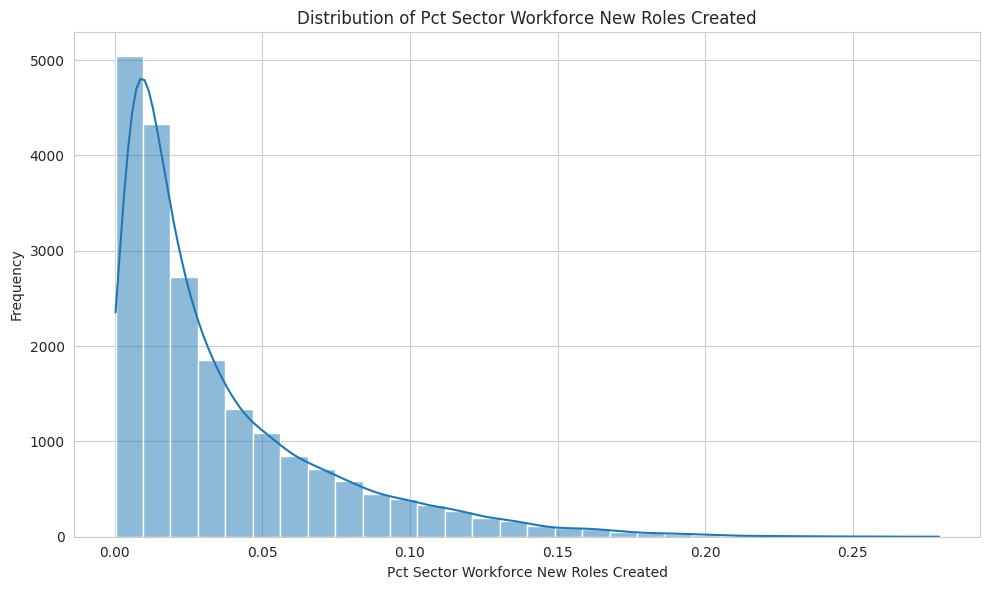

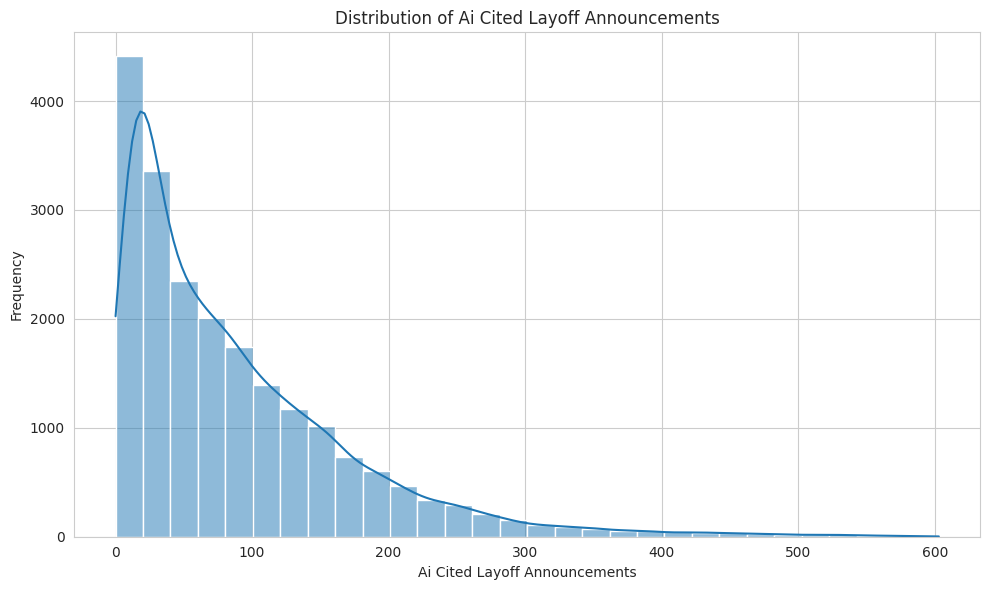

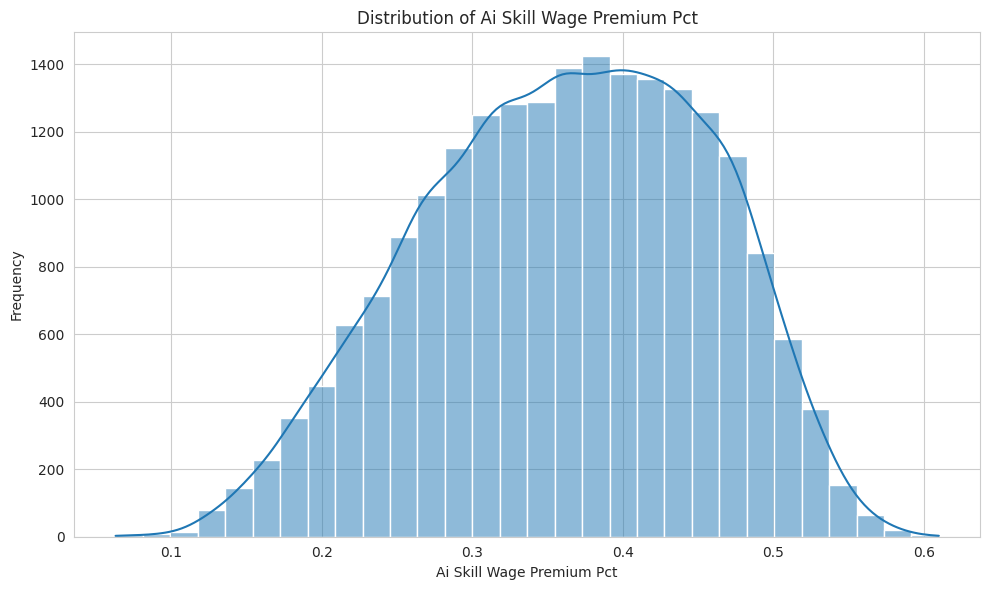

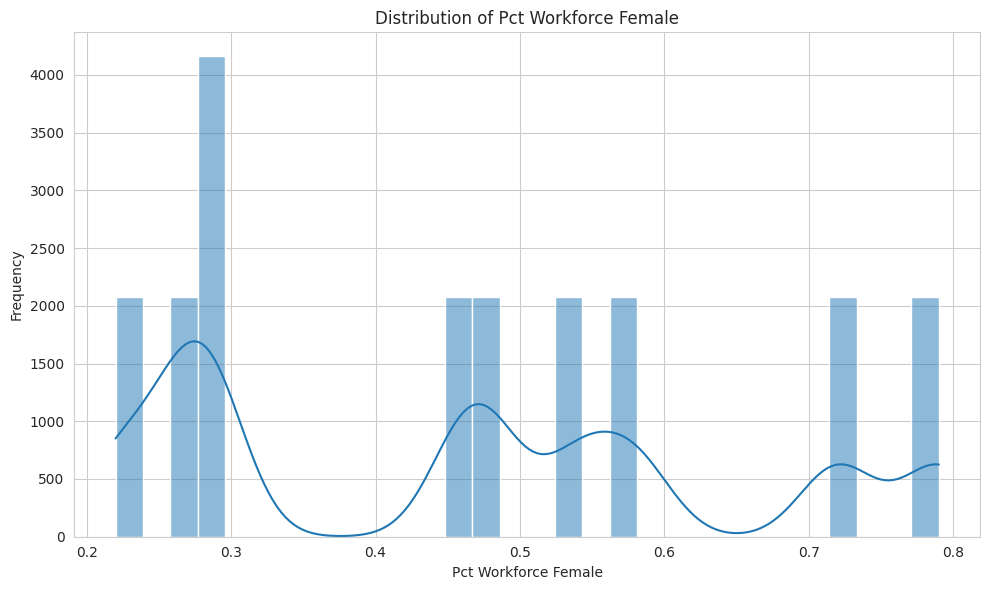

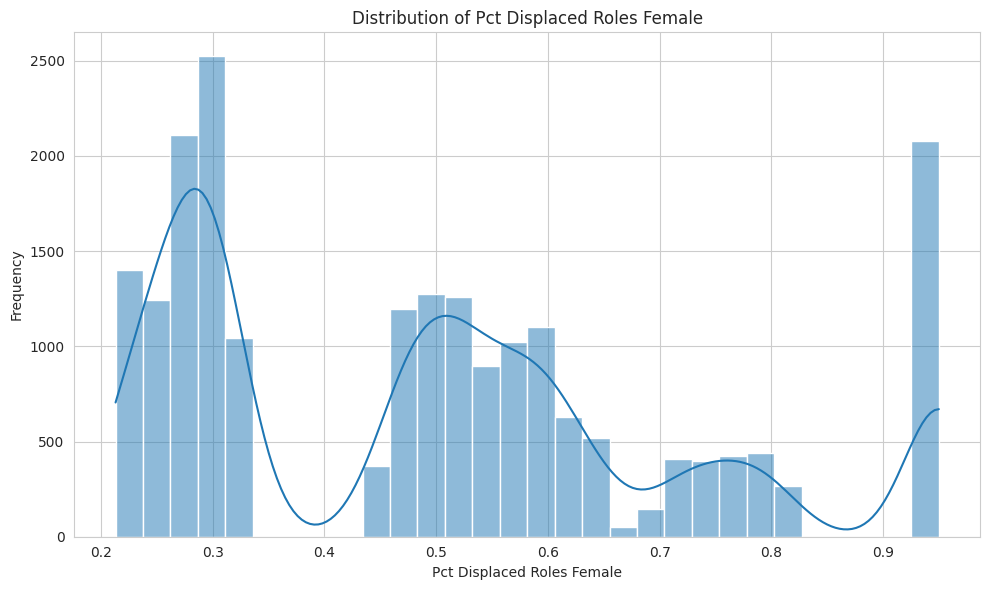

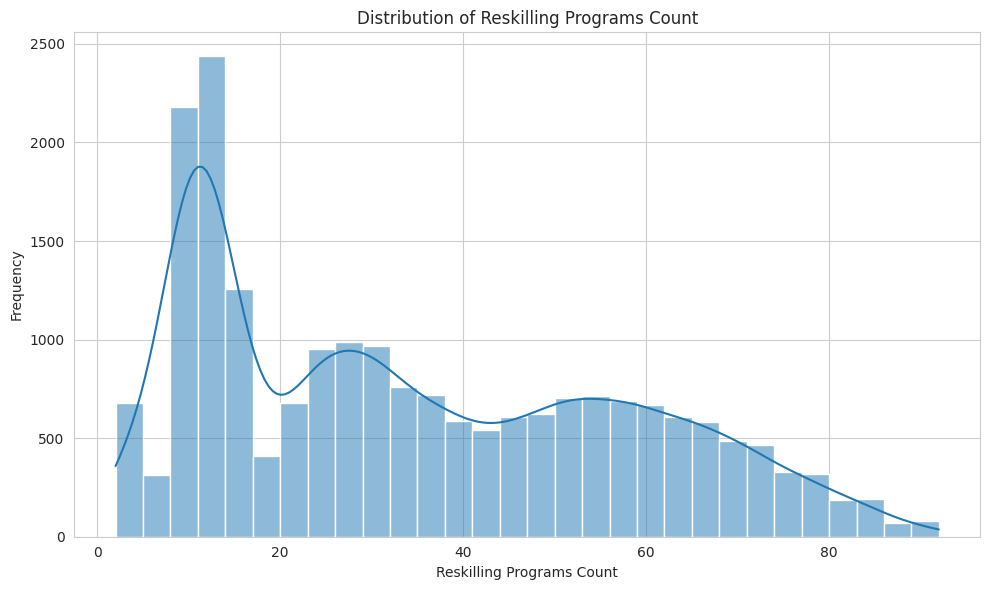

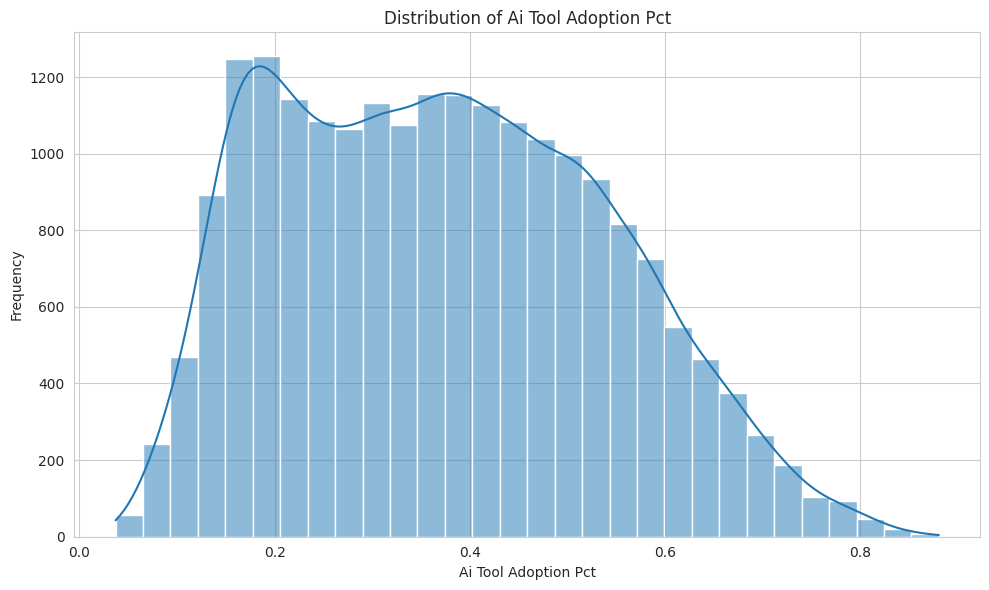

In [20]:
numerical_cols_to_plot = [
    'sector_automation_risk_score',
    'gdp_per_capita_usd',
    'ai_adoption_index',
    'pct_sector_workforce_displaced',
    'pct_sector_workforce_new_roles_created',
    'ai_cited_layoff_announcements',
    'ai_skill_wage_premium_pct',
    'pct_workforce_female',
    'pct_displaced_roles_female',
    'reskilling_programs_count',
    'ai_tool_adoption_pct'
]

sns.set_style("whitegrid")

for col in numerical_cols_to_plot:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

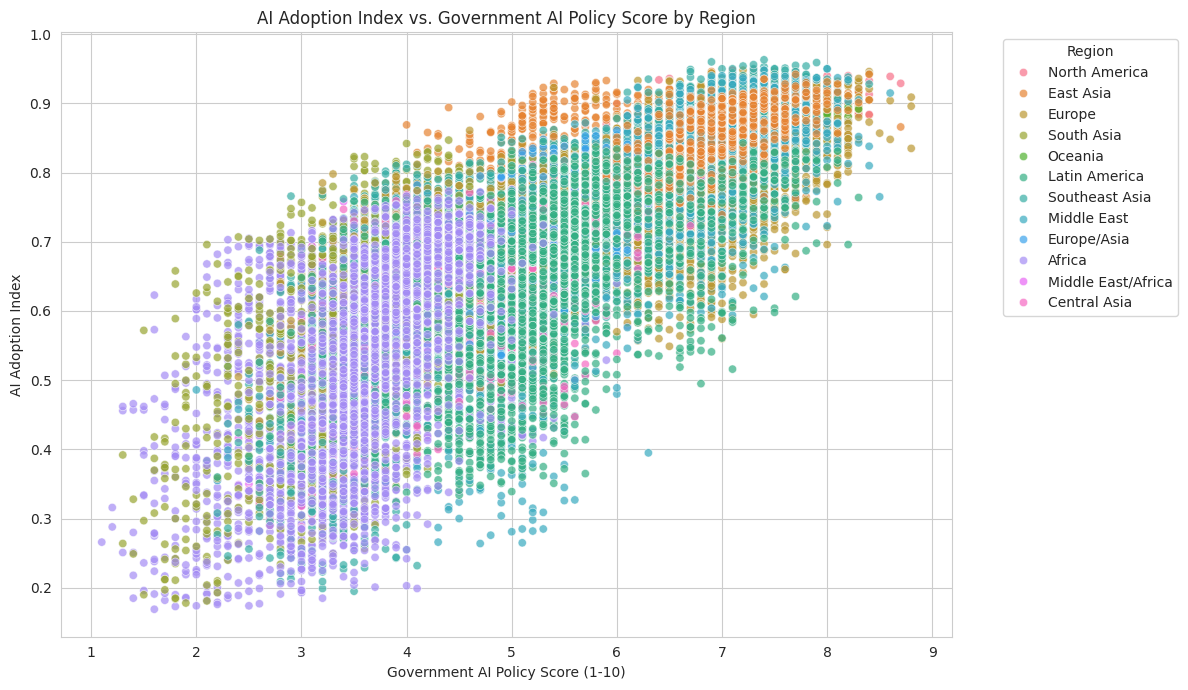

In [26]:
# Scatter plot: AI Adoption Index vs. Government AI Policy Score
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='govt_ai_policy_score_1_to_10', y='ai_adoption_index', hue='region', alpha=0.7)
plt.title('AI Adoption Index vs. Government AI Policy Score by Region')
plt.xlabel('Government AI Policy Score (1-10)')
plt.ylabel('AI Adoption Index')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

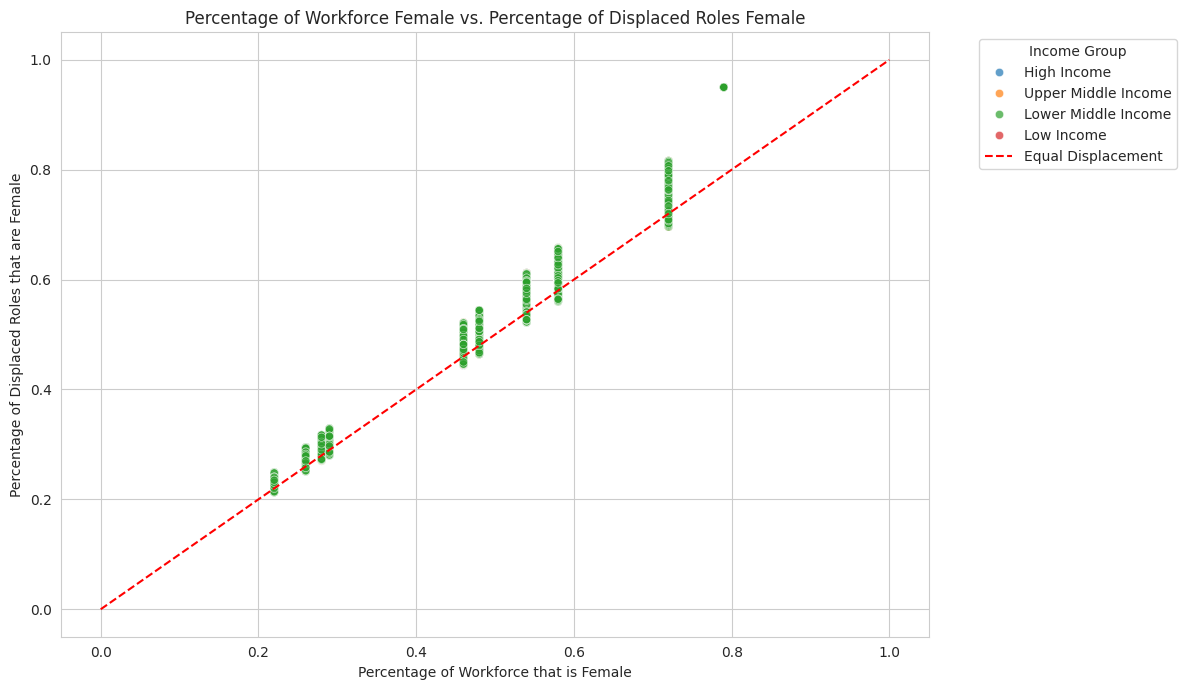

In [27]:
# Scatter plot: Percentage of Workforce Female vs. Percentage of Displaced Roles Female
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='pct_workforce_female', y='pct_displaced_roles_female', hue='income_group', alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--', label='Equal Displacement') # Reference line for equal displacement
plt.title('Percentage of Workforce Female vs. Percentage of Displaced Roles Female')
plt.xlabel('Percentage of Workforce that is Female')
plt.ylabel('Percentage of Displaced Roles that are Female')
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

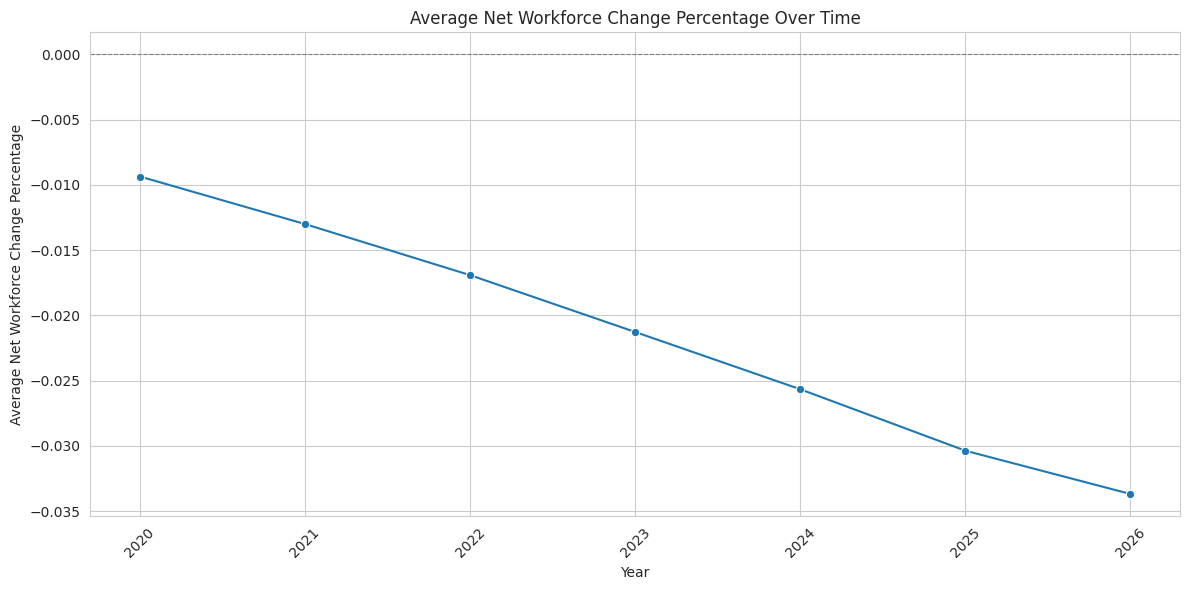

In [28]:
# Line plot: Net Workforce Change Percentage Over Time
net_workforce_change_yearly = df.groupby('year')['net_workforce_change_pct'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=net_workforce_change_yearly, x='year', y='net_workforce_change_pct', marker='o')
plt.title('Average Net Workforce Change Percentage Over Time')
plt.xlabel('Year')
plt.ylabel('Average Net Workforce Change Percentage')
plt.xticks(rotation=45)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line
plt.tight_layout()
plt.show()

/tmp/ipykernel_8223/2847048043.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income_group', y='ai_tool_adoption_pct', palette='coolwarm')


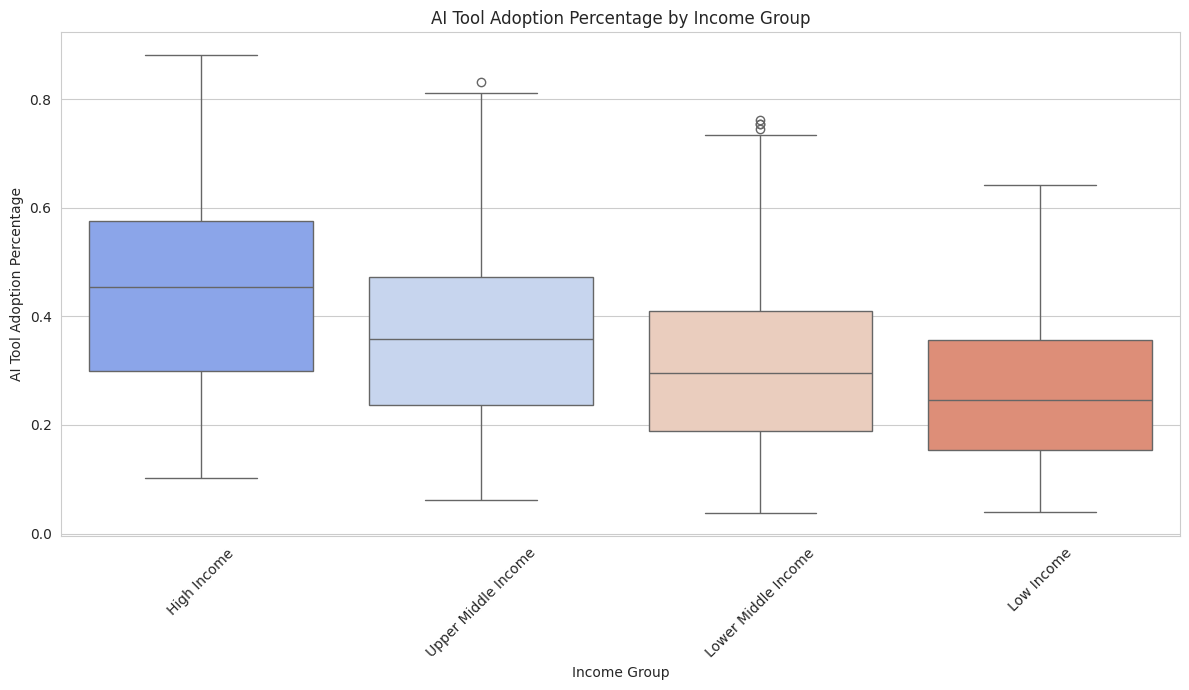

In [29]:
# Box plot: AI Tool Adoption Percentage by Income Group
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='income_group', y='ai_tool_adoption_pct', palette='coolwarm')
plt.title('AI Tool Adoption Percentage by Income Group')
plt.xlabel('Income Group')
plt.ylabel('AI Tool Adoption Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()